In [1]:
!pip install editdistance -q

import os, cv2, numpy as np, pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import zipfile

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms

import editdistance
import warnings
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

Device: cuda


In [2]:
from google.colab import files

print("Upload your dataset zip file now...")
uploaded = files.upload()  # a file picker will appear

# Get the uploaded zip filename automatically
zip_name = list(uploaded.keys())[0]
print(f"Uploaded: {zip_name}")

Upload your dataset zip file now...


Saving cig_ps (1).zip to cig_ps (1).zip
Uploaded: cig_ps (1).zip


In [3]:
extract_dir = '/content/dataset'
os.makedirs(extract_dir, exist_ok=True)

with zipfile.ZipFile(zip_name, 'r') as z:
    z.extractall(extract_dir)

print("Extracted contents:")
for root, dirs, files_list in os.walk(extract_dir):
    level = root.replace(extract_dir, '').count(os.sep)
    indent = '  ' * level
    print(f"{indent}{os.path.basename(root)}/")
    for f in files_list[:5]:   # show first 5 files per folder
        print(f"{indent}  {f}")
    if len(files_list) > 5:
        print(f"{indent}  ... and {len(files_list)-5} more files")

Extracted contents:
dataset/
  cig_ps/
    train-labels.csv
    train_images/
      train-2736.png
      train-704.png
      train-3489.png
      train-18908.png
      train-7006.png
      ... and 19995 more files
    test_images/
      test-4007.png
      test-3076.png
      test-483.png
      test-8.png
      test-1405.png
      ... and 4995 more files


In [5]:
# Paths based on your extracted folder structure
TRAIN_IMG_DIR = '/content/dataset/cig_ps/train_images'
TEST_IMG_DIR  = '/content/dataset/cig_ps/test_images'
LABEL_FILE    = '/content/dataset/cig_ps/train-labels.csv'

# Verify
print("Train images:", len(os.listdir(TRAIN_IMG_DIR)))
print("Test images :", len(os.listdir(TEST_IMG_DIR)))

df = pd.read_csv(LABEL_FILE)
print("\nCSV preview:")
print(df.head())
print("\nColumns:", df.columns.tolist())
print("Total training samples:", len(df))

Train images: 20000
Test images : 5000

CSV preview:
   Unnamed: 0        image    text
0           0  train-0.png  BU522X
1           1  train-1.png  XQ8NE2
2           2  train-2.png  DTZD3E
3           3  train-3.png  SM424H
4           4  train-4.png  6YVTQR

Columns: ['Unnamed: 0', 'image', 'text']
Total training samples: 20000


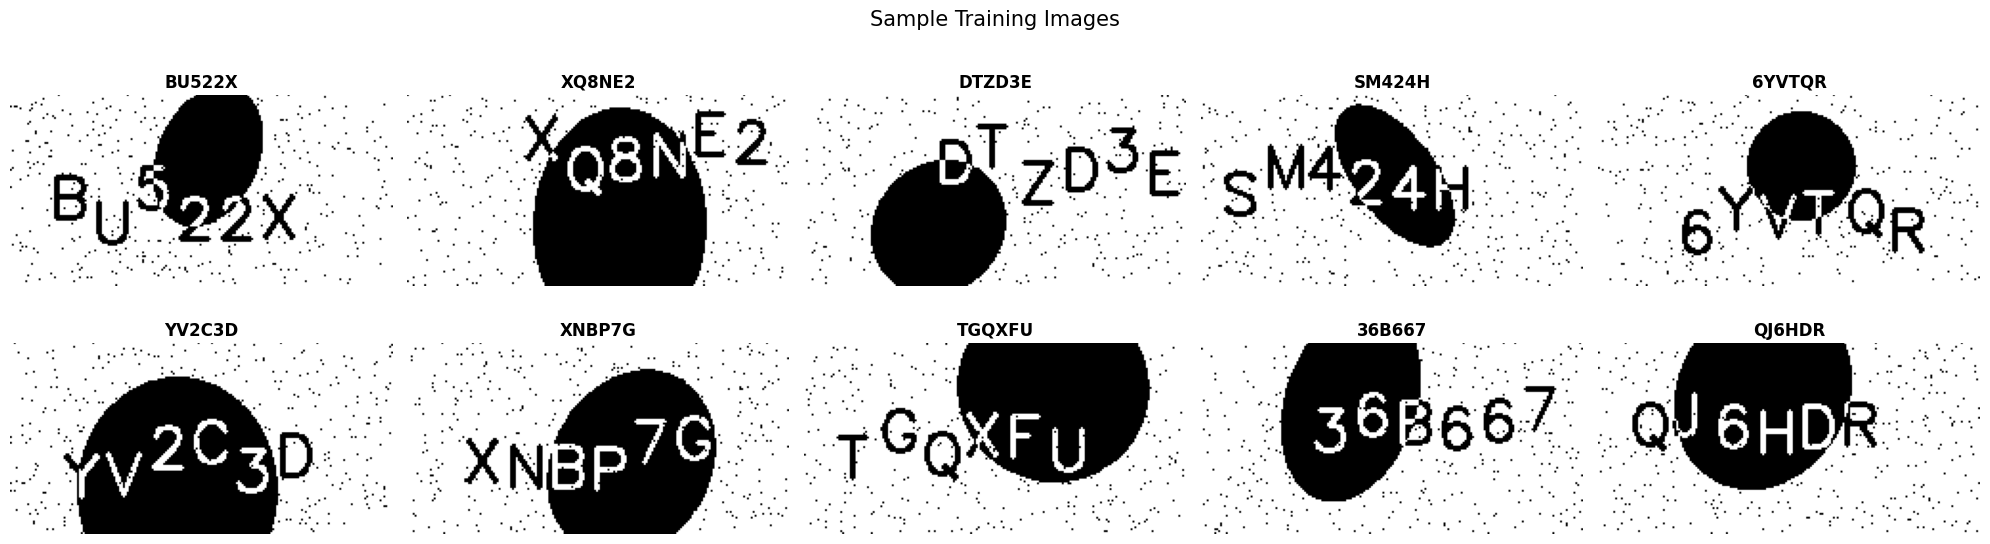

In [6]:
# Drop the unnamed index column
df = df[['image', 'text']].copy()

IMG_COL   = 'image'
LABEL_COL = 'text'

# Show 10 sample images with their labels
fig, axes = plt.subplots(2, 5, figsize=(20, 6))
for i, ax in enumerate(axes.flat):
    img_path = os.path.join(TRAIN_IMG_DIR, df[IMG_COL].iloc[i])
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    ax.imshow(img, cmap='gray')
    ax.set_title(df[LABEL_COL].iloc[i], fontsize=12, fontweight='bold')
    ax.axis('off')
plt.suptitle('Sample Training Images', fontsize=15)
plt.tight_layout()
plt.show()

In [7]:
# Check image dimensions
sample_img = cv2.imread(
    os.path.join(TRAIN_IMG_DIR, df[IMG_COL].iloc[0]),
    cv2.IMREAD_GRAYSCALE
)
print(f"Image shape (H x W): {sample_img.shape}")

# Label length distribution
df['label_len'] = df[LABEL_COL].str.len()
print(f"\nLabel lengths:")
print(df['label_len'].value_counts().sort_index())
print(f"\nMin: {df['label_len'].min()}  Max: {df['label_len'].max()}")

# Character frequency
all_chars = sorted(set(''.join(df[LABEL_COL].tolist())))
print(f"\nCharacter vocabulary ({len(all_chars)} chars):")
print(''.join(all_chars))

# Check for any nulls
print(f"\nNull values: {df.isnull().sum().sum()}")

Image shape (H x W): (100, 200)

Label lengths:
label_len
6    19998
8        1
9        1
Name: count, dtype: int64

Min: 6  Max: 9

Character vocabulary (38 chars):
+-.0123456789ABCDEFGHJKMNPQRSTUVWXYZar

Null values: 0


In [8]:
CHARS = ''.join(sorted(set(''.join(df[LABEL_COL].tolist()))))
print(f"CHARS: {CHARS}")
print(f"Vocab size: {len(CHARS)}")

# Index 0 reserved for CTC blank token
char2idx = {c: i + 1 for i, c in enumerate(CHARS)}
idx2char  = {i + 1: c for i, c in enumerate(CHARS)}
NUM_CLASSES  = len(CHARS)
MAX_LABEL_LEN = int(df['label_len'].max())

# Image size fed into model (standard for CRNN)
IMG_H = 32
IMG_W = 128

print(f"\nNUM_CLASSES : {NUM_CLASSES}")
print(f"MAX_LABEL_LEN: {MAX_LABEL_LEN}")
print(f"IMG_H x IMG_W: {IMG_H} x {IMG_W}")

CHARS: +-.0123456789ABCDEFGHJKMNPQRSTUVWXYZar
Vocab size: 38

NUM_CLASSES : 38
MAX_LABEL_LEN: 9
IMG_H x IMG_W: 32 x 128


In [9]:
from sklearn.model_selection import train_test_split

class CaptchaDataset(Dataset):
    def __init__(self, df, img_dir, char2idx,
                 img_h=32, img_w=128, augment=False):
        self.df       = df.reset_index(drop=True)
        self.img_dir  = img_dir
        self.char2idx = char2idx
        self.augment  = augment
        self.img_h    = img_h
        self.img_w    = img_w

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        fname = self.df[IMG_COL].iloc[idx]
        label = self.df[LABEL_COL].iloc[idx]

        # Read grayscale
        img = cv2.imread(
            os.path.join(self.img_dir, fname),
            cv2.IMREAD_GRAYSCALE
        )

        # Resize to fixed size
        img = cv2.resize(img, (self.img_w, self.img_h))

        # Augmentation (training only)
        if self.augment:
            # Random Gaussian blur
            if np.random.rand() < 0.4:
                k = np.random.choice([3, 5])
                img = cv2.GaussianBlur(img, (k, k), 0)
            # Random noise
            if np.random.rand() < 0.4:
                noise = np.random.normal(0, 12, img.shape).astype(np.int16)
                img = np.clip(img.astype(np.int16) + noise, 0, 255).astype(np.uint8)
            # Random brightness
            if np.random.rand() < 0.3:
                factor = np.random.uniform(0.8, 1.2)
                img = np.clip(img.astype(np.float32) * factor, 0, 255).astype(np.uint8)

        # Normalize to [-1, 1]
        img = img.astype(np.float32) / 255.0
        img = (img - 0.5) / 0.5
        img = torch.tensor(img, dtype=torch.float32).unsqueeze(0)  # (1, H, W)

        # Encode label — skip any char not in vocab
        target = [self.char2idx[c] for c in label if c in self.char2idx]
        return img, torch.tensor(target, dtype=torch.long), len(target)


print("CaptchaDataset class defined.")

CaptchaDataset class defined.


In [10]:
def collate_fn(batch):
    imgs, targets, lengths = zip(*batch)
    imgs = torch.stack(imgs)                         # (B, 1, H, W)

    max_len = max(lengths)
    padded  = torch.zeros(len(targets), max_len, dtype=torch.long)
    for i, t in enumerate(targets):
        padded[i, :len(t)] = t

    return imgs, padded, torch.tensor(lengths, dtype=torch.long)


print("collate_fn defined.")

collate_fn defined.


In [11]:
# Train / validation split — 90% train, 10% val
train_df, val_df = train_test_split(
    df, test_size=0.1, random_state=42, shuffle=True
)
train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)

# Datasets
train_ds = CaptchaDataset(train_df, TRAIN_IMG_DIR, char2idx,
                           img_h=IMG_H, img_w=IMG_W, augment=True)
val_ds   = CaptchaDataset(val_df,   TRAIN_IMG_DIR, char2idx,
                           img_h=IMG_H, img_w=IMG_W, augment=False)

# DataLoaders
train_loader = DataLoader(train_ds, batch_size=64, shuffle=True,
                          collate_fn=collate_fn, num_workers=2,
                          pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=64, shuffle=False,
                          collate_fn=collate_fn, num_workers=2,
                          pin_memory=True)

print(f"Train samples : {len(train_ds)}")
print(f"Val samples   : {len(val_ds)}")
print(f"Train batches : {len(train_loader)}")
print(f"Val batches   : {len(val_loader)}")

Train samples : 18000
Val samples   : 2000
Train batches : 282
Val batches   : 32


Image batch shape  : torch.Size([64, 1, 32, 128])
Targets shape      : torch.Size([64, 6])
Lengths            : [6, 6, 6, 6, 6, 6, 6, 6]

First sample decoded label: J273YU


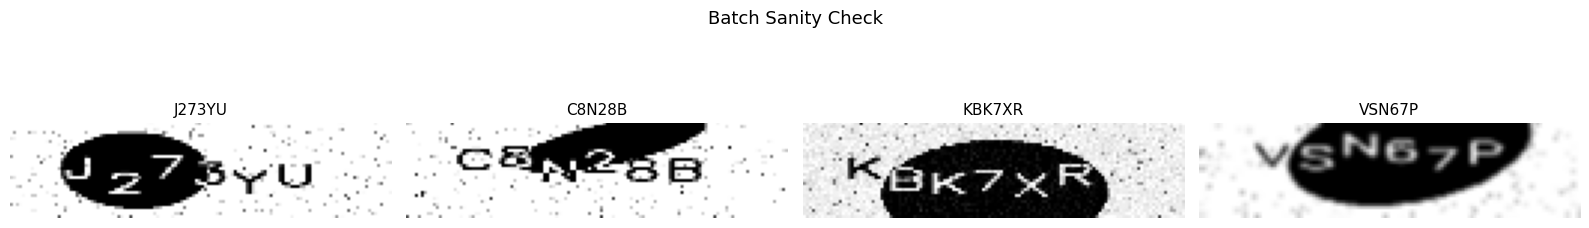

In [12]:
imgs, targets, lengths = next(iter(train_loader))

print(f"Image batch shape  : {imgs.shape}")       # (64, 1, 32, 128)
print(f"Targets shape      : {targets.shape}")    # (64, max_len)
print(f"Lengths            : {lengths[:8].tolist()}")

# Decode first sample to verify
sample_label = ''.join([idx2char[t.item()] for t in targets[0, :lengths[0]]])
print(f"\nFirst sample decoded label: {sample_label}")

# Visualise first 4 images
fig, axes = plt.subplots(1, 4, figsize=(16, 3))
for i, ax in enumerate(axes):
    ax.imshow(imgs[i].squeeze().numpy(), cmap='gray')
    lbl = ''.join([idx2char[t.item()] for t in targets[i, :lengths[i]]])
    ax.set_title(lbl, fontsize=11)
    ax.axis('off')
plt.suptitle('Batch Sanity Check', fontsize=13)
plt.tight_layout()
plt.show()

In [13]:
class CRNN(nn.Module):
    def __init__(self, num_classes, img_h=32):
        super().__init__()

        # ── CNN Block ──────────────────────────────────────────
        # Input: (B, 1, 32, 128)
        self.cnn = nn.Sequential(

            # Block 1 — (B, 64, 16, 64)
            nn.Conv2d(1, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # Block 2 — (B, 128, 8, 32)
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # Block 3 — (B, 256, 4, 32)
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=(2, 1)),   # only height halved

            # Block 4 — (B, 512, 2, 32)
            nn.Conv2d(256, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=(2, 1)),   # only height halved

            # Block 5 — (B, 512, 1, 32)  height → 1
            nn.Conv2d(512, 512, kernel_size=(2, 1)),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
        )

        # ── Dropout before RNN ─────────────────────────────────
        self.dropout = nn.Dropout(0.3)

        # ── BiLSTM sequence layers ─────────────────────────────
        # After CNN: feature size = 512 * 1 = 512  (H collapsed to 1)
        self.rnn1 = nn.LSTM(512, 256, bidirectional=True,
                            batch_first=True)
        self.rnn2 = nn.LSTM(512, 256, bidirectional=True,
                            batch_first=True)

        # ── Output projection ──────────────────────────────────
        # +1 for CTC blank token (index 0)
        self.fc = nn.Linear(512, num_classes + 1)

    def forward(self, x):
        # x: (B, 1, H, W)
        x = self.cnn(x)                    # (B, 512, 1, W')

        b, c, h, w = x.size()
        assert h == 1, f"Expected height=1 after CNN, got {h}"

        x = x.squeeze(2)                   # (B, 512, W')
        x = x.permute(0, 2, 1)            # (B, W', 512)
        x = self.dropout(x)

        x, _ = self.rnn1(x)               # (B, W', 512)
        x, _ = self.rnn2(x)               # (B, W', 512)

        x = self.fc(x)                    # (B, W', num_classes+1)
        x = x.permute(1, 0, 2)           # (W', B, num_classes+1) for CTC
        return x


print("CRNN model class defined.")

CRNN model class defined.


In [14]:
model = CRNN(num_classes=NUM_CLASSES, img_h=IMG_H).to(device)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
train_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters     : {total_params:,}")
print(f"Trainable parameters : {train_params:,}")

# Shape check with a dummy batch
dummy = torch.zeros(2, 1, IMG_H, IMG_W).to(device)
with torch.no_grad():
    out = model(dummy)

print(f"\nInput shape  : {dummy.shape}")       # (2, 1, 32, 128)
print(f"Output shape : {out.shape}")           # (T, 2, NUM_CLASSES+1)
print(f"T (time steps) = {out.shape[0]}")      # should be ~32
print(f"C (classes+1)  = {out.shape[2]}")      # should be NUM_CLASSES+1 = 39

Total parameters     : 8,202,919
Trainable parameters : 8,202,919

Input shape  : torch.Size([2, 1, 32, 128])
Output shape : torch.Size([32, 2, 39])
T (time steps) = 32
C (classes+1)  = 39


In [15]:
def greedy_decode(output, idx2char):
    """
    output: (T, B, C) tensor — raw logits from model
    Returns list of decoded strings, one per batch item
    """
    preds = output.argmax(2)          # (T, B) — best class each timestep
    preds = preds.permute(1, 0)       # (B, T)
    results = []
    for seq in preds:
        chars, prev = [], None
        for idx in seq.tolist():
            if idx != 0 and idx != prev:   # skip blank (0) and repeats
                chars.append(idx2char.get(idx, ''))
            prev = idx
        results.append(''.join(chars))
    return results


def compute_cer(predictions, targets):
    """
    Character Error Rate using Levenshtein distance.
    Lower is better. 0.0 = perfect.
    """
    total_dist, total_len = 0, 0
    for pred, tgt in zip(predictions, targets):
        total_dist += editdistance.eval(pred, tgt)
        total_len  += len(tgt)
    return total_dist / max(total_len, 1)


print("greedy_decode and compute_cer defined.")

greedy_decode and compute_cer defined.


In [17]:
criterion = nn.CTCLoss(blank=0, zero_infinity=True)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=4
)

print("Loss, optimizer, scheduler ready.")

Loss, optimizer, scheduler ready.


In [18]:
def validate(model, loader, criterion, idx2char):
    model.eval()
    all_preds, all_labels = [], []
    total_loss = 0

    with torch.no_grad():
        for imgs, targets, target_lens in loader:
            imgs = imgs.to(device)

            output   = model(imgs)                    # (T, B, C)
            log_prob = output.log_softmax(2)
            T, B, _  = log_prob.size()

            input_lens = torch.full((B,), T, dtype=torch.long).to(device)

            # Flatten targets for CTCLoss
            flat_tgts  = []
            flat_lens  = []
            for i in range(B):
                l = target_lens[i].item()
                flat_tgts.extend(targets[i, :l].tolist())
                flat_lens.append(l)

            flat_tgts = torch.tensor(flat_tgts, dtype=torch.long).to(device)
            flat_lens = torch.tensor(flat_lens,  dtype=torch.long).to(device)

            loss = criterion(log_prob, flat_tgts, input_lens, flat_lens)
            total_loss += loss.item()

            # Decode predictions
            preds = greedy_decode(output, idx2char)
            all_preds.extend(preds)

            # Decode ground truth
            for i in range(B):
                l   = target_lens[i].item()
                lbl = ''.join([idx2char[t.item()] for t in targets[i, :l]])
                all_labels.append(lbl)

    avg_loss = total_loss / len(loader)
    cer      = compute_cer(all_preds, all_labels)
    exact    = sum(p == g for p, g in zip(all_preds, all_labels)) / len(all_labels)
    return avg_loss, cer, exact, all_preds, all_labels


print("validate() function defined.")

validate() function defined.


In [19]:
EPOCHS    = 50
save_path = 'best_model.pth'
best_cer  = float('inf')

train_loss_history = []
val_cer_history    = []

for epoch in range(1, EPOCHS + 1):

    # ── Training ──────────────────────────────────────────────
    model.train()
    epoch_loss = 0

    for batch_idx, (imgs, targets, target_lens) in enumerate(train_loader):
        imgs = imgs.to(device)

        optimizer.zero_grad()
        output   = model(imgs)
        log_prob = output.log_softmax(2)
        T, B, _  = log_prob.size()

        input_lens = torch.full((B,), T, dtype=torch.long).to(device)

        flat_tgts = []
        flat_lens = []
        for i in range(B):
            l = target_lens[i].item()
            flat_tgts.extend(targets[i, :l].tolist())
            flat_lens.append(l)

        flat_tgts = torch.tensor(flat_tgts, dtype=torch.long).to(device)
        flat_lens = torch.tensor(flat_lens,  dtype=torch.long).to(device)

        loss = criterion(log_prob, flat_tgts, input_lens, flat_lens)
        loss.backward()

        # Gradient clipping — prevents exploding gradients
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)

        optimizer.step()
        epoch_loss += loss.item()

    avg_train_loss = epoch_loss / len(train_loader)

    # ── Validation ────────────────────────────────────────────
    val_loss, val_cer, val_exact, _, _ = validate(
        model, val_loader, criterion, idx2char
    )

    scheduler.step(val_cer)

    train_loss_history.append(avg_train_loss)
    val_cer_history.append(val_cer)

    # Save best model
    if val_cer < best_cer:
        best_cer = val_cer
        torch.save(model.state_dict(), save_path)
        tag = '  ← best saved'
    else:
        tag = ''

    print(
        f"Epoch {epoch:03d}/{EPOCHS} | "
        f"Train Loss: {avg_train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val CER: {val_cer:.4f} | "
        f"Exact: {val_exact:.4f}"
        f"{tag}"
    )

print(f"\nTraining complete. Best Val CER: {best_cer:.4f}")

Epoch 001/50 | Train Loss: 3.8263 | Val Loss: 3.7984 | Val CER: 1.0000 | Exact: 0.0000  ← best saved
Epoch 002/50 | Train Loss: 2.4126 | Val Loss: 0.6935 | Val CER: 0.2178 | Exact: 0.2365  ← best saved
Epoch 003/50 | Train Loss: 0.3816 | Val Loss: 0.1689 | Val CER: 0.0506 | Exact: 0.7355  ← best saved
Epoch 004/50 | Train Loss: 0.1648 | Val Loss: 0.1169 | Val CER: 0.0382 | Exact: 0.7900  ← best saved
Epoch 005/50 | Train Loss: 0.1101 | Val Loss: 0.0756 | Val CER: 0.0230 | Exact: 0.8675  ← best saved
Epoch 006/50 | Train Loss: 0.0894 | Val Loss: 0.0479 | Val CER: 0.0146 | Exact: 0.9155  ← best saved
Epoch 007/50 | Train Loss: 0.0766 | Val Loss: 0.1036 | Val CER: 0.0312 | Exact: 0.8250
Epoch 008/50 | Train Loss: 0.0635 | Val Loss: 0.0515 | Val CER: 0.0142 | Exact: 0.9180  ← best saved
Epoch 009/50 | Train Loss: 0.0567 | Val Loss: 0.0657 | Val CER: 0.0178 | Exact: 0.8995
Epoch 010/50 | Train Loss: 0.0510 | Val Loss: 0.0537 | Val CER: 0.0148 | Exact: 0.9115
Epoch 011/50 | Train Loss: 0.053

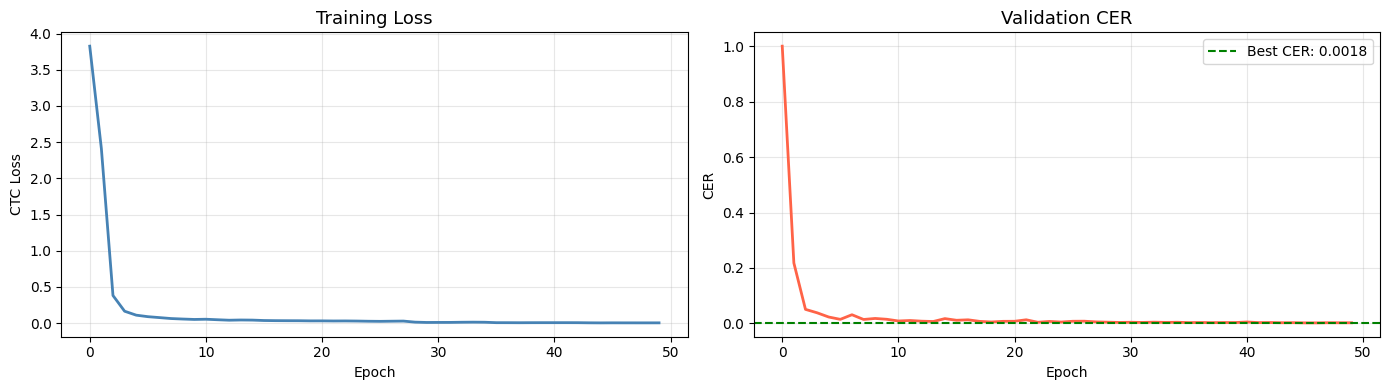

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(train_loss_history, color='steelblue', linewidth=2)
axes[0].set_title('Training Loss', fontsize=13)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('CTC Loss')
axes[0].grid(True, alpha=0.3)

axes[1].plot(val_cer_history, color='tomato', linewidth=2)
axes[1].axhline(y=best_cer, color='green', linestyle='--',
                label=f'Best CER: {best_cer:.4f}')
axes[1].set_title('Validation CER', fontsize=13)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('CER')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [21]:
# Load best model and show sample predictions
model.load_state_dict(torch.load(save_path, map_location=device))
_, final_cer, final_exact, preds, labels = validate(
    model, val_loader, criterion, idx2char
)

print(f"Final Val CER        : {final_cer:.4f}")
print(f"Final Exact Match    : {final_exact:.4f}")
print(f"\n{'Ground Truth':<15} {'Predicted':<15} {'Match'}")
print('-' * 40)
for gt, pr in zip(labels[:20], preds[:20]):
    match = '✓' if gt == pr else '✗'
    print(f"{gt:<15} {pr:<15} {match}")

Final Val CER        : 0.0018
Final Exact Match    : 0.9890

Ground Truth    Predicted       Match
----------------------------------------
48TADN          48TADN          ✓
9JEGA6          9JEGA6          ✓
3JY9FC          3JY9FC          ✓
GXNHGU          GXNHGU          ✓
B4238J          B4238J          ✓
E5TJ97          E5TJ97          ✓
F5QPKZ          F5QPKZ          ✓
4GRFCD          4GRFCD          ✓
95JQV6          95JQV6          ✓
H3DMAW          H3DMAW          ✓
U48BHM          U48BHM          ✓
BESG7W          BESG7W          ✓
MT2W8S          MT2W8S          ✓
DKMPAM          DKMPAM          ✓
J6U76F          J6U76F          ✓
MT3TS8          MT3TS8          ✓
M9YU2F          M9YU2F          ✓
WR5YS8          WR5YS8          ✓
ZBR6RH          ZBR6RH          ✓
YGZXZX          YGZXZX          ✓


In [22]:
class TestDataset(Dataset):
    def __init__(self, img_dir, img_h=32, img_w=128):
        self.img_dir   = img_dir
        self.filenames = sorted(
            os.listdir(img_dir),
            key=lambda x: int(x.split('-')[1].split('.')[0])  # sort by number
        )
        self.img_h = img_h
        self.img_w = img_w

    def __len__(self):
        return len(self.filenames)

    def __getitem__(self, idx):
        fname = self.filenames[idx]
        img   = cv2.imread(
            os.path.join(self.img_dir, fname),
            cv2.IMREAD_GRAYSCALE
        )
        img = cv2.resize(img, (self.img_w, self.img_h))
        img = img.astype(np.float32) / 255.0
        img = (img - 0.5) / 0.5
        img = torch.tensor(img, dtype=torch.float32).unsqueeze(0)
        return img, fname


test_ds     = TestDataset(TEST_IMG_DIR, img_h=IMG_H, img_w=IMG_W)
test_loader = DataLoader(test_ds, batch_size=64, shuffle=False, num_workers=2)

print(f"Test samples: {len(test_ds)}")
print(f"First 5 files: {test_ds.filenames[:5]}")

Test samples: 5000
First 5 files: ['test-0.png', 'test-1.png', 'test-2.png', 'test-3.png', 'test-4.png']


In [23]:
# Load best saved model
model.load_state_dict(torch.load(save_path, map_location=device))
model.eval()

results = []

with torch.no_grad():
    for imgs, fnames in test_loader:
        imgs   = imgs.to(device)
        output = model(imgs)                    # (T, B, C)
        preds  = greedy_decode(output, idx2char)

        for fname, pred in zip(fnames, preds):
            results.append({
                'image'     : fname,
                'prediction': pred
            })

submission = pd.DataFrame(results)
print(f"Total predictions : {len(submission)}")
print("\nSample predictions:")
print(submission.head(10).to_string(index=False))

Total predictions : 5000

Sample predictions:
     image prediction
test-0.png     QVTQ8A
test-1.png     7PSW9D
test-2.png     WJ2WNY
test-3.png     RFHJD4
test-4.png     K7ZUF2
test-5.png     CPMUBK
test-6.png     UZDRAW
test-7.png     2YDPJR
test-8.png     H5SG63
test-9.png     B2Z823


In [24]:
NAME   = 'Bhanothu_Priyanka'
ENROLL = '24115047'

csv_filename      = f'submission_{NAME}_{ENROLL}.csv'
notebook_filename = f'notebook_{NAME}_{ENROLL}.ipynb'

submission.to_csv(csv_filename, index=False)
print(f"Saved: {csv_filename}")
print(f"\nFirst 5 rows of submission:")
print(submission.head().to_string(index=False))
print(f"\nTotal rows: {len(submission)}")

Saved: submission_Bhanothu_Priyanka_24115047.csv

First 5 rows of submission:
     image prediction
test-0.png     QVTQ8A
test-1.png     7PSW9D
test-2.png     WJ2WNY
test-3.png     RFHJD4
test-4.png     K7ZUF2

Total rows: 5000


In [27]:
from google.colab import drive
drive.mount('/content/drive', force_remount=False)

# ── Folder on your Drive where submission goes ──
DRIVE_FOLDER = f'/content/drive/MyDrive/CIG_AIML_Submission'
os.makedirs(DRIVE_FOLDER, exist_ok=True)

# Copy CSV
import shutil
shutil.copy(csv_filename, os.path.join(DRIVE_FOLDER, csv_filename))
print(f"CSV saved to Drive: {DRIVE_FOLDER}/{csv_filename}")

# Copy model checkpoint too (useful backup)
shutil.copy(save_path, os.path.join(DRIVE_FOLDER, save_path))
print(f"Model saved to Drive: {DRIVE_FOLDER}/{save_path}")

print("\nDrive folder contents:")
for f in os.listdir(DRIVE_FOLDER):
    print(f"  {f}")

Mounted at /content/drive
CSV saved to Drive: /content/drive/MyDrive/CIG_AIML_Submission/submission_Bhanothu_Priyanka_24115047.csv
Model saved to Drive: /content/drive/MyDrive/CIG_AIML_Submission/best_model.pth

Drive folder contents:
  submission_Bhanothu_Priyanka_24115047.csv
  best_model.pth


In [28]:
from google.colab import files
files.download(csv_filename)
print(f"Download started: {csv_filename}")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Download started: submission_Bhanothu_Priyanka_24115047.csv
